# Surrogate/oracle design — dual datasets, **output PCA** targets

Two coordinated train/val/test splits to pick a **surrogate** (dataset 1) and **oracle** (dataset 2):
val sets disjoint, `S_test ⊆ O_train`, `O_test ⊆ S_train`; per-sample dual labels saved for in-sample/OOD
design eval.

Models predict a **PCA-reduced spectrum** (32 components, fit on each dataset's train spectra) instead of the
raw 1002-dim curve — fewer output params, denoised target, less overfitting; reconstructed for all metrics/plots.
Compared: 5 MLP readouts (mean/min/max/std/concat) and 5 CNNs (mean/min/max/std/concat), param-matched.

## 0. Setup + data + per-residue embeddings

In [1]:
import csv, os, numpy as np, torch, torch.nn as nn, hashlib
import arcadia_pycolor as apc, fp_models as fpm
from sklearn.decomposition import PCA
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True; apc.mpl.setup()
except Exception: HAVE_PLT=False
TD="training_data"; DS=os.path.join("..","fpbase-extractor","processed_data","ESM-spectrum")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(TD,"split_assignments.csv")))); N=len(rows)
Y=np.load(os.path.join(TD,"spectra.npy")).astype(np.float32); grid=np.load(os.path.join(DS,"grid_nm.npy")); G=len(grid)
EMM=np.array([float(r["em_max"]) for r in rows]); EXM=np.array([float(r["ex_max"]) for r in rows])
H=np.load(os.path.join(TD,"esm_residue_fp16.npy")); Ls=np.load(os.path.join(TD,"esm_residue_len.npy")); Lmax=H.shape[1]
Ht=torch.tensor(H); ar=torch.arange(Lmax); os.makedirs("trained_models",exist_ok=True)
def batches(idx,bs=32,shuffle=False):
    idx=np.array(idx)
    if shuffle: np.random.shuffle(idx)
    for i in range(0,len(idx),bs):
        b=idx[i:i+bs]
        yield Ht[b].float().to(dev),(ar.unsqueeze(0)<torch.tensor(Ls[b]).unsqueeze(1)).to(dev),b
print("device",dev,"| N",N)

device mps | N 453


## 1. Two coordinated splits (+ dual labels)

In [2]:
SPLIT_SEED=0
rng=np.random.default_rng(SPLIT_SEED); perm=rng.permutation(N)
n_te=int(round(0.15*N)); n_va=int(round(0.15*N))
Srole=np.array(["train"]*N); Srole[perm[:n_te]]="test"; Srole[perm[n_te:n_te+n_va]]="val"
s_train=perm[n_te+n_va:]
st=np.random.default_rng(SPLIT_SEED+1).permutation(s_train)
Orole=np.array(["train"]*N); Orole[st[:n_te]]="test"; Orole[st[n_te:n_te+n_va]]="val"
assert np.all(Orole[Srole=="test"]=="train") and np.all(Srole[Orole=="test"]=="train")
assert np.sum((Srole=="val")&(Orole=="val"))==0
def cnt(a): return {b:int((a==b).sum()) for b in("train","val","test")}
print("surrogate (S):", cnt(Srole), "| oracle (O):", cnt(Orole))
with open(os.path.join(TD,"dual_splits.csv"),"w",newline="") as fh:
    w=csv.writer(fh); w.writerow(["index","slug","name","surrogate_role","oracle_role"])
    for i,r in enumerate(rows): w.writerow([i,r.get("slug",""),r.get("name",""),Srole[i],Orole[i]])
SIDX={b:np.where(Srole==b)[0] for b in("train","val","test")}
OIDX={b:np.where(Orole==b)[0] for b in("train","val","test")}

surrogate (S): {'train': 317, 'val': 68, 'test': 68} | oracle (O): {'train': 317, 'val': 68, 'test': 68}


## 2. Models (param-matched, PCA-coeff output) + train/eval + cache

PCA (32 comps) is fit per dataset on its **train** spectra; models regress the coefficients, which are
reconstructed to spectra for every metric and plot.

In [3]:
PCA_N=32; DROP=0.2; LR=1e-3; WD=1e-4; EP_MLP=300; EP_CNN=150; FORCE=False
cnn_ref=fpm.SpectrumNet("max",True,conv_ch=128,k=5,hidden=256,nl=2,out=PCA_N)
BUDGET=sum(p.numel() for p in cnn_ref.parameters())
def mlp_hidden(d_in,nl=4,out=PCA_N):
    pf=lambda Hd: d_in*Hd+Hd+(nl-1)*(Hd*Hd+Hd)+Hd*out+out
    return min(range(32,2049,4), key=lambda Hd: abs(pf(Hd)-BUDGET))
MODELS=[]
for inp in ["mean","min","max","std","concat"]:
    d_in=1280*(4 if inp=="concat" else 1)
    MODELS.append(dict(type="mlp", input=inp, hidden=mlp_hidden(d_in), nl=4, sid=f"mlp-{inp}"))
for pool in ["mean","min","max","std","concat"]:
    MODELS.append(dict(type="cnn", pool=pool, sid=f"cnn-{pool}"))
def build(spec):
    if spec["type"]=="mlp":
        return fpm.PooledMLP(spec["input"], spec["hidden"], spec["nl"], out=PCA_N, drop=DROP).to(dev)
    return fpm.SpectrumNet(spec["pool"], True, conv_ch=128, k=5, hidden=256, nl=2, out=PCA_N, drop=DROP).to(dev)

def exem(S): return grid[np.argmax(S[:,:G],1)], grid[np.argmax(S[:,G:],1)]
def predict_spectrum(net, idx, pca):
    net.eval(); cs=[]
    with torch.no_grad():
        for Hb,mk,b in batches(idx): cs.append(net(Hb,mk).cpu().numpy())
    return pca.inverse_transform(np.concatenate(cs))           # coeffs -> spectrum
def evaluate(net, idx, pca):
    P=predict_spectrum(net, idx, pca); T=Y[idx]; ex,em=exem(P)
    return dict(mse=float(((P-T)**2).mean()), em_mae=float(np.abs(em-EMM[idx]).mean()))
def fit(net,tr,va,Ycoef_t,pca,epochs):
    opt=torch.optim.Adam(net.parameters(),LR,weight_decay=WD); lf=nn.MSELoss(); best=1e9; bst=None
    for ep in range(epochs):
        net.train()
        for Hb,mk,b in batches(tr,shuffle=True):
            opt.zero_grad(); lf(net(Hb,mk), Ycoef_t[torch.as_tensor(b,device=dev)]).backward(); opt.step()
        v=evaluate(net,va,pca)["mse"]
        if v<best: best=v; bst={k:vv.cpu().clone() for k,vv in net.state_dict().items()}
    net.load_state_dict(bst); return net

DATASIG=hashlib.md5(Srole.tobytes()+Orole.tobytes()).hexdigest()[:8]
def get_or_train(spec, dsname, tr, va, te, pca, Ycoef_t):
    path=os.path.join("trained_models", f"dual_{dsname}_{spec['sid']}_pca{PCA_N}_{DATASIG}.pt")
    if os.path.exists(path) and not FORCE:
        net,ck=fpm.load_model(path,dev,out=PCA_N); met=dict(ck["metrics"])
        if "train" not in met: met["train"]=evaluate(net,tr,pca)
        return met, True, path
    net=build(spec); fit(net,tr,va,Ycoef_t,pca, EP_MLP if spec["type"]=="mlp" else EP_CNN)
    met={"train":evaluate(net,tr,pca), "val":evaluate(net,va,pca), "test":evaluate(net,te,pca)}
    if spec["type"]=="mlp":
        meta=dict(kind="pooledmlp", input=spec["input"], hidden=spec["hidden"], nl=spec["nl"], drop=DROP, out=PCA_N)
    else:
        meta=dict(kind="spectrumnet", arch="CNN", pool=spec["pool"], conv_ch=128, k=5, hidden=256, nl=2, drop=DROP, out=PCA_N)
    meta.update(sid=spec["sid"], metrics=met)
    fpm.save_model(path, net, meta); return met, False, path
print("budget (CNN, out=PCA):", f"{BUDGET:,}")

budget (CNN, out=PCA): 1,008,416


## 3-4. Run both datasets → pick surrogate (dataset 1) and oracle (dataset 2)

In [4]:
def run(dsname, IDX):
    pca=PCA(PCA_N, random_state=0).fit(Y[IDX["train"]])
    Ycoef_t=torch.tensor(pca.transform(Y), dtype=torch.float32, device=dev)
    print(f"=== {dsname} dataset === (PCA {PCA_N} comps, EVR {pca.explained_variance_ratio_.sum():.3f})")
    table=[]
    for spec in MODELS:
        met,cached,path=get_or_train(spec, dsname, IDX["train"], IDX["val"], IDX["test"], pca, Ycoef_t)
        table.append((spec,met,path))
        print(f"  {spec['sid']:11s} {'(cached)' if cached else '(trained)'} | "
              f"train {met['train']['mse']:.5f} | val {met['val']['mse']:.5f} em {met['val']['em_mae']:4.1f} | "
              f"test {met['test']['mse']:.5f} em {met['test']['em_mae']:4.1f}")
    best=min(table, key=lambda t: t[1]["val"]["mse"])
    print(f"  -> best by val: {best[0]['sid']} ({best[1]['val']['mse']:.5f})")
    return table, best, pca

surr_table, surr_best, surr_pca = run("surr", SIDX)
orac_table, orac_best, orac_pca = run("orac", OIDX)

=== surr dataset === (PCA 32 comps, EVR 0.995)


  mlp-mean    (cached) | train 0.02832 | val 0.03090 em 25.2 | test 0.02703 em 18.7
  mlp-min     (cached) | train 0.02826 | val 0.02933 em 23.8 | test 0.02830 em 20.5
  mlp-max     (cached) | train 0.03088 | val 0.02927 em 24.4 | test 0.02952 em 25.1
  mlp-std     (cached) | train 0.04768 | val 0.04367 em 39.8 | test 0.04429 em 37.8
  mlp-concat  (cached) | train 0.02494 | val 0.02911 em 28.1 | test 0.02990 em 24.9
  cnn-mean    (cached) | train 0.02808 | val 0.03031 em 25.6 | test 0.02667 em 20.1


  cnn-min     (cached) | train 0.03107 | val 0.02893 em 19.0 | test 0.03101 em 23.4
  cnn-max     (cached) | train 0.00394 | val 0.02847 em 22.7 | test 0.01929 em 12.0


  cnn-std     (cached) | train 0.03200 | val 0.02873 em 22.7 | test 0.02906 em 21.2


  cnn-concat  (cached) | train 0.01030 | val 0.02824 em 24.8 | test 0.02153 em 14.8
  -> best by val: cnn-concat (0.02824)
=== orac dataset === (PCA 32 comps, EVR 0.996)
  mlp-mean    (cached) | train 0.00925 | val 0.02899 em 22.3 | test 0.03303 em 22.8
  mlp-min     (cached) | train 0.02431 | val 0.02893 em 22.6 | test 0.03464 em 26.1


  mlp-max     (cached) | train 0.02407 | val 0.02923 em 26.9 | test 0.03558 em 28.1


  mlp-std     (cached) | train 0.03300 | val 0.03453 em 22.9 | test 0.03552 em 26.1


  mlp-concat  (cached) | train 0.02312 | val 0.02935 em 19.2 | test 0.03367 em 25.1
  cnn-mean    (cached) | train 0.01774 | val 0.03096 em 24.1 | test 0.03210 em 24.9
  cnn-min     (cached) | train 0.01272 | val 0.02875 em 21.5 | test 0.03399 em 25.9
  cnn-max     (cached) | train 0.00304 | val 0.02409 em 20.9 | test 0.02780 em 20.3
  cnn-std     (cached) | train 0.00576 | val 0.02666 em 22.8 | test 0.03171 em 25.0
  cnn-concat  (cached) | train 0.00362 | val 0.02709 em 20.7 | test 0.02839 em 22.9
  -> best by val: cnn-max (0.02409)


## 5. Save chosen models + train/val/test bars

surrogate (best MLP, dataset 1) <- mlp-concat | val 0.02911
oracle    (best CNN, dataset 2) <- cnn-max | val 0.02409


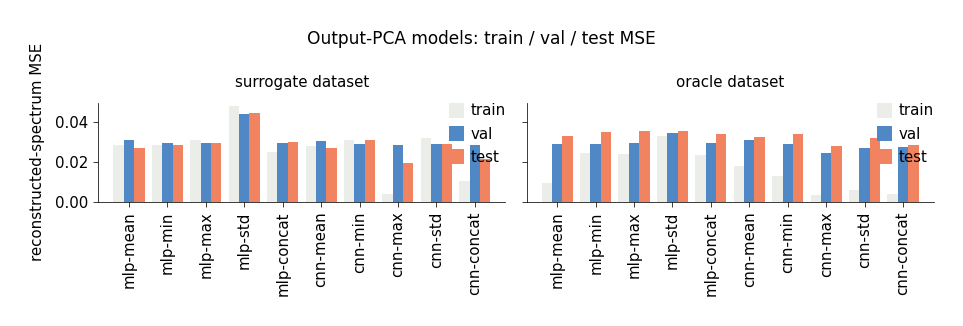

In [5]:
import shutil
# surrogate = best MLP on dataset 1; oracle = best CNN on dataset 2 (by validation MSE)
surr_pick=min([t for t in surr_table if t[0]["type"]=="mlp"], key=lambda t: t[1]["val"]["mse"])
orac_pick=min([t for t in orac_table if t[0]["type"]=="cnn"], key=lambda t: t[1]["val"]["mse"])
shutil.copy(surr_pick[2], os.path.join("trained_models","dual_surrogate_net.pt"))
shutil.copy(orac_pick[2], os.path.join("trained_models","dual_oracle_net.pt"))
import joblib
joblib.dump(surr_pca, os.path.join("trained_models","dual_surrogate_pca.joblib"))   # surrogate net predicts in this PCA basis
joblib.dump(orac_pca, os.path.join("trained_models","dual_oracle_pca.joblib"))       # oracle net predicts in this PCA basis
print(f"surrogate (best MLP, dataset 1) <- {surr_pick[0]['sid']} | val {surr_pick[1]['val']['mse']:.5f}")
print(f"oracle    (best CNN, dataset 2) <- {orac_pick[0]['sid']} | val {orac_pick[1]['val']['mse']:.5f}")
if HAVE_PLT:
    fig,ax=plt.subplots(1,2,figsize=(13,4),sharey=True)
    for a,(name,tbl) in zip(ax,[("surrogate dataset",surr_table),("oracle dataset",orac_table)]):
        sids=[s["sid"] for s,_,_ in tbl]
        tr=[m["train"]["mse"] for _,m,_ in tbl]; vv=[m["val"]["mse"] for _,m,_ in tbl]; tt=[m["test"]["mse"] for _,m,_ in tbl]
        x=np.arange(len(sids)); w=0.27
        a.bar(x-w,tr,w,color=apc.gray,label="train"); a.bar(x,vv,w,color=apc.aegean,label="val"); a.bar(x+w,tt,w,color=apc.amber,label="test")
        a.set_xticks(x); a.set_xticklabels(sids,rotation=90); a.set_title(name); a.legend()
    ax[0].set_ylabel("reconstructed-spectrum MSE")
    plt.suptitle("Output-PCA models: train / val / test MSE"); plt.tight_layout(); plt.show()

## 6. Surrogate top-5: example-by-example on validation

Ground truth = rose, prediction = blue (ex dashed, em solid); the same validation proteins across all top-5 models.

top-5 (S_val MSE): ['cnn-concat 0.0282', 'cnn-max 0.0285', 'cnn-std 0.0287', 'cnn-min 0.0289', 'mlp-concat 0.0291']


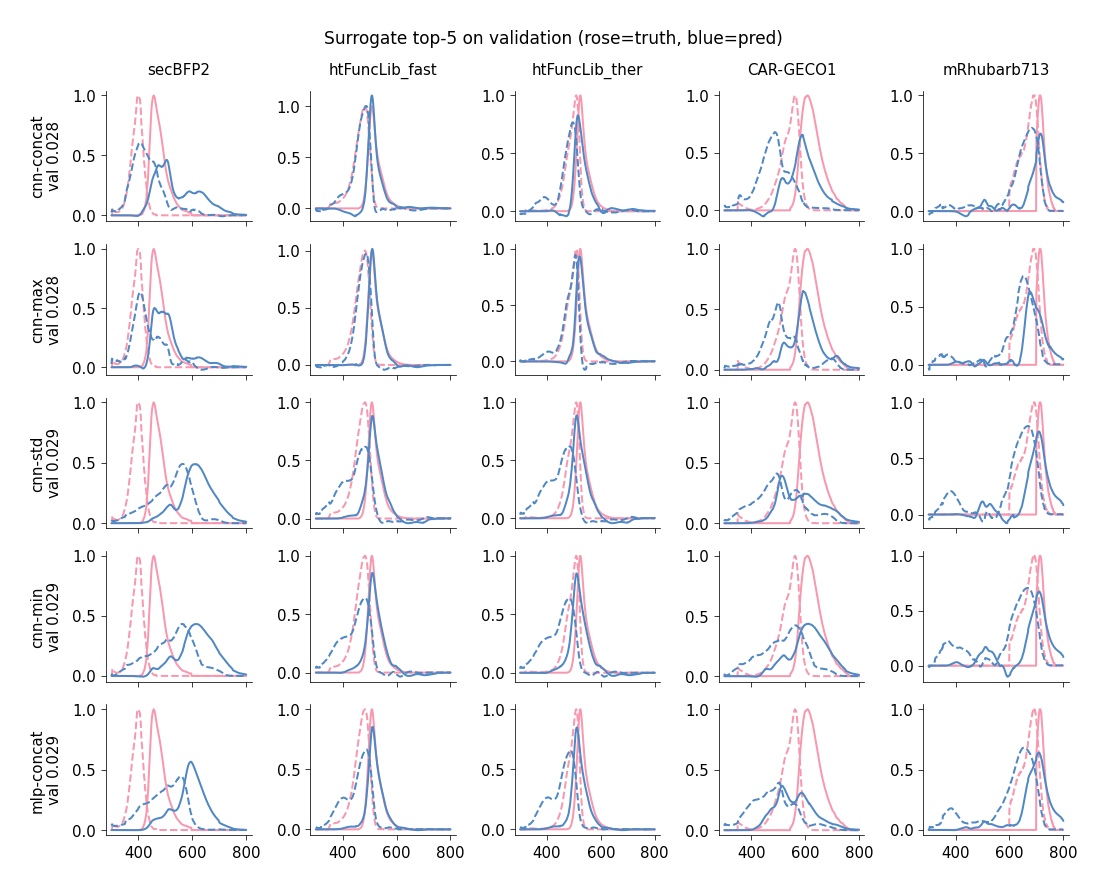

In [6]:
def span(idx,k):
    idx=np.array(idx); order=idx[np.argsort(EMM[idx])]
    return order[np.linspace(0,len(order)-1,min(k,len(order))).astype(int)]
K=5
top5=sorted(surr_table, key=lambda t: t[1]["val"]["mse"])[:5]
print("top-5 (S_val MSE):", [f"{t[0]['sid']} {t[1]['val']['mse']:.4f}" for t in top5])
vex=span(SIDX["val"], K)
if HAVE_PLT:
    fig,axes=plt.subplots(len(top5),K,figsize=(3*K,2.4*len(top5)),sharex=True)
    for r,(spec,met,path) in enumerate(top5):
        net,_=fpm.load_model(path,dev,out=PCA_N); P=predict_spectrum(net,vex,surr_pca)
        for c,i in enumerate(vex):
            a=axes[r,c]
            a.plot(grid,Y[i,:G],color=apc.rose,ls="--"); a.plot(grid,Y[i,G:],color=apc.rose,ls="-")
            a.plot(grid,P[c,:G],color=apc.aegean,ls="--"); a.plot(grid,P[c,G:],color=apc.aegean,ls="-")
            if r==0: a.set_title(rows[i]["name"][:14])
            if c==0: a.set_ylabel(f"{spec['sid']}\nval {met['val']['mse']:.3f}")
    plt.suptitle("Surrogate top-5 on validation (rose=truth, blue=pred)"); plt.tight_layout(); plt.show()

### 6b. Parity scatter — predicted vs true peak (top-5, train vs val)

Predicted vs true ex_max (top) and em_max (bottom); train=blue, val=amber, dashed y=x.

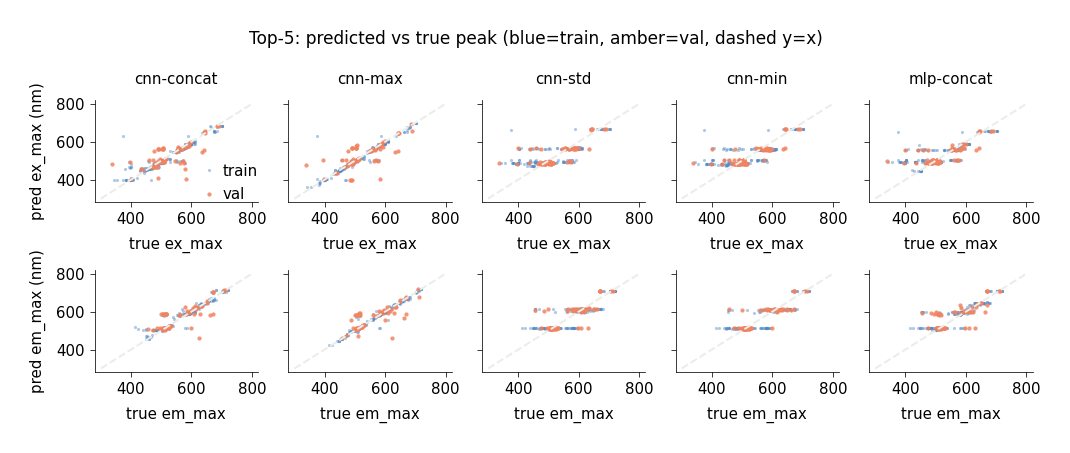

In [7]:
def pred_peaks(net, idx, pca):
    P=predict_spectrum(net, idx, pca); return grid[np.argmax(P[:,:G],1)], grid[np.argmax(P[:,G:],1)]
if HAVE_PLT:
    lo,hi=float(grid[0]),float(grid[-1])
    fig,axes=plt.subplots(2,len(top5),figsize=(2.9*len(top5),5.8),sharex='row',sharey='row')
    for c,(spec,met,path) in enumerate(top5):
        net,_=fpm.load_model(path,dev,out=PCA_N)
        ex_tr,em_tr=pred_peaks(net,SIDX["train"],surr_pca); ex_va,em_va=pred_peaks(net,SIDX["val"],surr_pca)
        for row,(tt,pt,tv,pv,lab) in enumerate([
            (EXM[SIDX["train"]],ex_tr,EXM[SIDX["val"]],ex_va,"ex_max"),
            (EMM[SIDX["train"]],em_tr,EMM[SIDX["val"]],em_va,"em_max")]):
            a=axes[row,c]; a.plot([lo,hi],[lo,hi],ls="--",color=apc.gray)
            a.scatter(tt,pt,s=10,color=apc.aegean,alpha=0.45,label="train")
            a.scatter(tv,pv,s=18,color=apc.amber,alpha=0.85,label="val")
            if row==0: a.set_title(spec["sid"])
            if c==0: a.set_ylabel(f"pred {lab} (nm)")
            a.set_xlabel(f"true {lab}")
    axes[0,0].legend(loc="lower right")
    plt.suptitle("Top-5: predicted vs true peak (blue=train, amber=val, dashed y=x)"); plt.tight_layout(); plt.show()

## 7. Oracle by split region (dual labels)

Best oracle model on three regions. **Ground truth = rose, oracle prediction = seaweed.**
- **S_train ∩ O_train** — oracle in-sample.
- **S_test ∩ O_train** (=surrogate-test) — oracle in-sample, surrogate-OOD (judges OOD designs here).
- **S_train ∩ O_test** (=oracle-test) — oracle held-out (certifies its accuracy).

oracle = cnn-max
region                    n      MSE  em_MAE
S_train ∩ O_train       181  0.00281     5.0


S_test ∩ O_train         68  0.00248     3.2
S_train ∩ O_test         68  0.02780    20.3


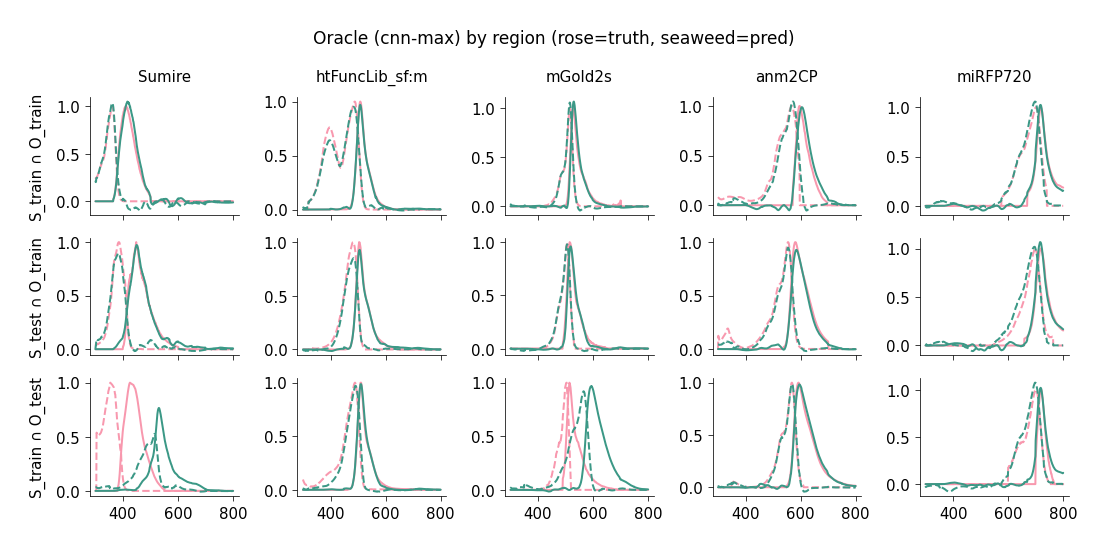

In [8]:
oracle_net,_=fpm.load_model(orac_pick[2], dev, out=PCA_N)
groups=[("S_train ∩ O_train", np.intersect1d(SIDX["train"],OIDX["train"])),
        ("S_test ∩ O_train",  np.intersect1d(SIDX["test"], OIDX["train"])),
        ("S_train ∩ O_test",  np.intersect1d(SIDX["train"],OIDX["test"]))]
print(f"oracle = {orac_pick[0]['sid']}")
print(f"{'region':22s} {'n':>4} {'MSE':>8} {'em_MAE':>7}")
for name,idx in groups:
    m=evaluate(oracle_net, idx, orac_pca); print(f"{name:22s} {len(idx):>4} {m['mse']:8.5f} {m['em_mae']:7.1f}")
if HAVE_PLT:
    fig,axes=plt.subplots(len(groups),K,figsize=(3*K,2.4*len(groups)),sharex=True)
    for r,(name,idx) in enumerate(groups):
        ex=span(idx,K); P=predict_spectrum(oracle_net,ex,orac_pca)
        for c,i in enumerate(ex):
            a=axes[r,c]
            a.plot(grid,Y[i,:G],color=apc.rose,ls="--"); a.plot(grid,Y[i,G:],color=apc.rose,ls="-")
            a.plot(grid,P[c,:G],color=apc.seaweed,ls="--"); a.plot(grid,P[c,G:],color=apc.seaweed,ls="-")
            if r==0: a.set_title(rows[i]["name"][:14])
            if c==0: a.set_ylabel(name)
    plt.suptitle(f"Oracle ({orac_pick[0]['sid']}) by region (rose=truth, seaweed=pred)"); plt.tight_layout(); plt.show()

## Notes
- Output is **PCA-reduced** (32 comps, fit per dataset on train). All metrics/plots are in reconstructed
  spectrum space. Cache key includes `pcaN`, so PCA and non-PCA checkpoints don't collide.
- `dual_splits.csv` labels each FP with surrogate/oracle roles for in-sample vs OOD design evaluation.